# Лабораторная работа: Анализ и предварительная обработка временного ряда PM2.5

## 0. Установка зависимостей и импорт библиотек

In [2]:
%pip install pyts

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
from scipy.signal import savgol_filter
from pyts.decomposition import SingularSpectrumAnalysis

## 1. Загрузка данных, формирование временного индекса и выбор выборки

In [54]:
df = pd.read_csv('/content/BeijingPM20100101_20151231.csv')

In [55]:
df.head(5)

,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec
0,1,2010,1,1,0,4,NaN,NaN,NaN,NaN,-21.0,43.0,1021.0,-11.0,NW,1.79,0.0,0.0
1,2,2010,1,1,1,4,NaN,NaN,NaN,NaN,-21.0,47.0,1020.0,-12.0,NW,4.92,0.0,0.0
2,3,2010,1,1,2,4,NaN,NaN,NaN,NaN,-21.0,43.0,1019.0,-11.0,NW,6.71,0.0,0.0
3,4,2010,1,1,3,4,NaN,NaN,NaN,NaN,-21.0,55.0,1019.0,-14.0,NW,9.84,0.0,0.0
4,5,2010,1,1,4,4,NaN,NaN,NaN,NaN,-20.0,51.0,1018.0,-12.0,NW,12.97,0.0,0.0


In [56]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [57]:
df.sort_values(by='datetime', inplace=True)

In [58]:
df = df.set_index('datetime', drop=False)

In [59]:
df

,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec,datetime
datetime,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,1,2010,1,1,0,4,NaN,NaN,NaN,NaN,-21.0,43.0,1021.0,-11.0,NW,1.79,0.0,0.0,2010-01-01 00:00:00
2010-01-01 01:00:00,2,2010,1,1,1,4,NaN,NaN,NaN,NaN,-21.0,47.0,1020.0,-12.0,NW,4.92,0.0,0.0,2010-01-01 01:00:00
2010-01-01 02:00:00,3,2010,1,1,2,4,NaN,NaN,NaN,NaN,-21.0,43.0,1019.0,-11.0,NW,6.71,0.0,0.0,2010-01-01 02:00:00
2010-01-01 03:00:00,4,2010,1,1,3,4,NaN,NaN,NaN,NaN,-21.0,55.0,1019.0,-14.0,NW,9.84,0.0,0.0,2010-01-01 03:00:00
2010-01-01 04:00:00,5,2010,1,1,4,4,NaN,NaN,NaN,NaN,-20.0,51.0,1018.0,-12.0,NW,12.97,0.0,0.0,2010-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 19:00:00,52580,2015,12,31,19,4,140.0,157.0,122.0,133.0,-8.0,68.0,1031.0,-3.0,SE,7.14,0.0,0.0,2015-12-31 19:00:00
2015-12-31 20:00:00,52581,2015,12,31,20,4,157.0,199.0,149.0,169.0,-8.0,63.0,1030.0,-2.0,SE,8.03,0.0,0.0,2015-12-31 20:00:00
2015-12-31 21:00:00,52582,2015,12,31,21,4,171.0,231.0,196.0,203.0,-10.0,73.0,1030.0,-6.0,NE,0.89,0.0,0.0,2015-12-31 21:00:00


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
deltas = df['datetime'].diff()
print(deltas.value_counts())
#шкала регулярна, цикл - каждый час.

datetime
0 days 01:00:00    52583
Name: count, dtype: int64


In [62]:
final_df = df.tail(1000)

In [63]:
final_df

,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec,datetime
datetime,,,,,,,,,,,,,,,,,,,
2015-11-20 08:00:00,51585,2015,11,20,8,3,43.0,56.0,47.0,49.0,0.0,100.0,1027.0,0.0,SE,7.16,0.0,0.0,2015-11-20 08:00:00
2015-11-20 09:00:00,51586,2015,11,20,9,3,53.0,68.0,56.0,61.0,0.0,NaN,NaN,0.0,SE,8.95,0.0,0.0,2015-11-20 09:00:00
2015-11-20 10:00:00,51587,2015,11,20,10,3,62.0,NaN,70.0,71.0,0.0,NaN,NaN,0.0,cv,0.89,0.0,0.0,2015-11-20 10:00:00
2015-11-20 11:00:00,51588,2015,11,20,11,3,71.0,NaN,78.0,87.0,0.0,NaN,NaN,1.0,SE,1.79,0.4,0.4,2015-11-20 11:00:00
2015-11-20 12:00:00,51589,2015,11,20,12,3,79.0,NaN,80.0,100.0,1.0,NaN,NaN,1.0,SE,3.58,0.2,0.6,2015-11-20 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 19:00:00,52580,2015,12,31,19,4,140.0,157.0,122.0,133.0,-8.0,68.0,1031.0,-3.0,SE,7.14,0.0,0.0,2015-12-31 19:00:00
2015-12-31 20:00:00,52581,2015,12,31,20,4,157.0,199.0,149.0,169.0,-8.0,63.0,1030.0,-2.0,SE,8.03,0.0,0.0,2015-12-31 20:00:00
2015-12-31 21:00:00,52582,2015,12,31,21,4,171.0,231.0,196.0,203.0,-10.0,73.0,1030.0,-6.0,NE,0.89,0.0,0.0,2015-12-31 21:00:00


## 2. Предварительная обработка данных и визуализация целевого ряда

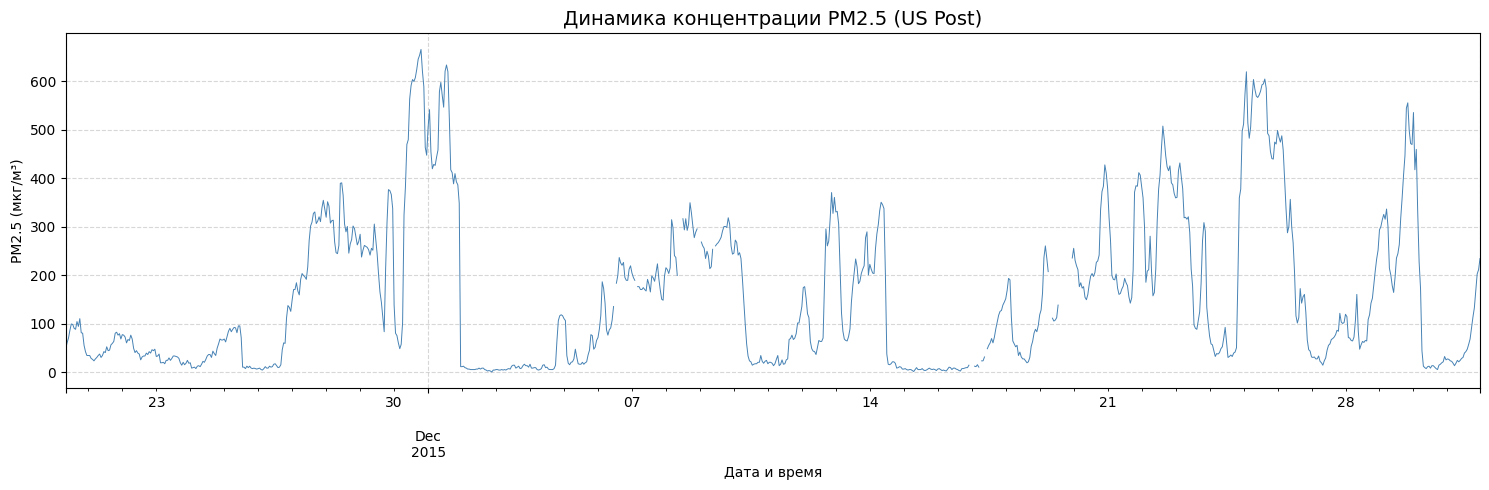

In [64]:
plt.figure(figsize=(15, 5))
final_df['PM_US Post'].plot(linewidth=0.7, color='steelblue')
plt.title('Динамика концентрации PM2.5 (US Post)', fontsize=14)
plt.xlabel('Дата и время')
plt.ylabel('PM2.5 (мкг/м³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [65]:
final_df.drop(['PM_Dongsi', 'PM_Dongsihuan', 'PM_Nongzhanguan'], axis=1, inplace=True)

/tmp/ipykernel_1473/157846469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.drop(['PM_Dongsi', 'PM_Dongsihuan', 'PM_Nongzhanguan'], axis=1, inplace=True)


In [66]:
final_df.drop(['DEWP', 'HUMI', 'PRES', 'TEMP','cbwd','Iws','precipitation'], axis=1, inplace=True)

/tmp/ipykernel_1473/3397760598.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.drop(['DEWP', 'HUMI', 'PRES', 'TEMP','cbwd','Iws','precipitation'], axis=1, inplace=True)


In [67]:
final_df.drop('Iprec', axis=1, inplace=True)

/tmp/ipykernel_1473/1687526275.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.drop('Iprec', axis=1, inplace=True)


In [68]:
series = final_df['PM_US Post']

In [69]:
series

,PM_US Post
datetime,
2015-11-20 08:00:00,49.0
2015-11-20 09:00:00,61.0
2015-11-20 10:00:00,71.0
2015-11-20 11:00:00,87.0
2015-11-20 12:00:00,100.0
...,...
2015-12-31 19:00:00,133.0
2015-12-31 20:00:00,169.0
2015-12-31 21:00:00,203.0


In [70]:
series.isna().sum()

np.int64(22)

In [71]:
missing_rows = series[series.isna()]
missing_rows

,PM_US Post
datetime,
2015-12-06 12:00:00,NaN
2015-12-07 03:00:00,NaN
2015-12-08 09:00:00,NaN
2015-12-08 10:00:00,NaN
2015-12-08 11:00:00,NaN
2015-12-08 23:00:00,NaN
2015-12-09 00:00:00,NaN
2015-12-09 10:00:00,NaN
2015-12-16 23:00:00,NaN


In [72]:
series = series.interpolate(method='time', limit=7)

In [73]:
series.isna().sum()

np.int64(0)

## 3. Проверка стационарности исходного ряда

### 3.1. Расширенный критерий Дики – Фуллера (ADF)

In [74]:
alpha = 0.05

#расширенный критерий Дики - Фуллера
adf = adfuller(series, autolag='AIC')
adf_stat = adf[0]
adf_pvalue = adf[1]

/tmp/ipykernel_1473/815208979.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(series, autolag='AIC')


In [75]:
print(f'АДФ статистика : {adf_stat}')
print(f'АДФ pvalue : {adf_pvalue}')

АДФ статистика : -4.452996962594329
АДФ pvalue : 0.00023888815597612693


In [76]:
if adf_pvalue < alpha:
  print('HO отвергается, ряд стационарен')
else:
  print('H0 не отвергается, ряд не стационарен')

HO отвергается, ряд стационарен


### 3.2. Критерий Квятковского – Филлипса – Шмидта – Шина (KPSS)

In [77]:
kps = kpss(series, regression='c', nlags='auto')
kps_stat = kps[0]
kps_pvalue = kps[1]

/tmp/ipykernel_1473/1505875482.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kps = kpss(series, regression='c', nlags='auto')
/tmp/ipykernel_1473/1505875482.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kps = kpss(series, regression='c', nlags='auto')


In [78]:
print(f'КФШШ статистика : {kps_stat}')
print(f'КФШШ pvalue : {kps_pvalue}')

КФШШ статистика : 0.25944951890122925
КФШШ pvalue : 0.1


In [79]:
if kps_pvalue < alpha:
    print("H0 отвергается. Ряд НЕСТАЦИОНАРЕН.")
else:
    print("H0 не отвергается. Ряд СТАЦИОНАРЕН.")

H0 не отвергается. Ряд СТАЦИОНАРЕН.


## 4. Обнаружение аномальных значений (выбросов)

### 4.1. Метод межквантильного размаха (IQR)

In [80]:
#выбросы межквантильным размахом:
q1 = series.quantile(0.25)
q3 = series.quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers_mask = (series < lower_bound) | (series > upper_bound)
outliers = series[outliers_mask]
len(outliers)

19

### 4.2. Метод медианного абсолютного отклонения (MAD)

In [81]:
#выбросы медианным абсолютным отклонением
median = series.median()
d_med = (series - median).abs().median()
zi = 0.6745 * (series - median) / d_med
outliers_mask1 = zi.abs() > 3.5
outliers1 = series[outliers_mask1]
len(outliers1)

30

### 4.3. фильтр Хампеля

In [82]:
def hampel_filter(series, window_size=25, n_sigmas=3):
    k = 1.4826
    rolling_median = series.rolling(window=window_size, center=True, min_periods=1).median()
    rolling_diff = (series - rolling_median).abs()
    rolling_mad = rolling_diff.rolling(window=window_size, center=True, min_periods=1).median()
    threshold = n_sigmas * k * rolling_mad
    outliers_mask3 = rolling_diff > threshold
    return outliers_mask3, rolling_median

In [83]:
outliers_mask3, local_medians = hampel_filter(series, window_size=25, n_sigmas=3)
outliers = final_df[outliers_mask3]
print(f"Найдено выбросов фильтром Хампеля: {len(outliers)}")

Найдено выбросов фильтром Хампеля: 50


## 5. Графическое сопоставление обнаруженных выбросов

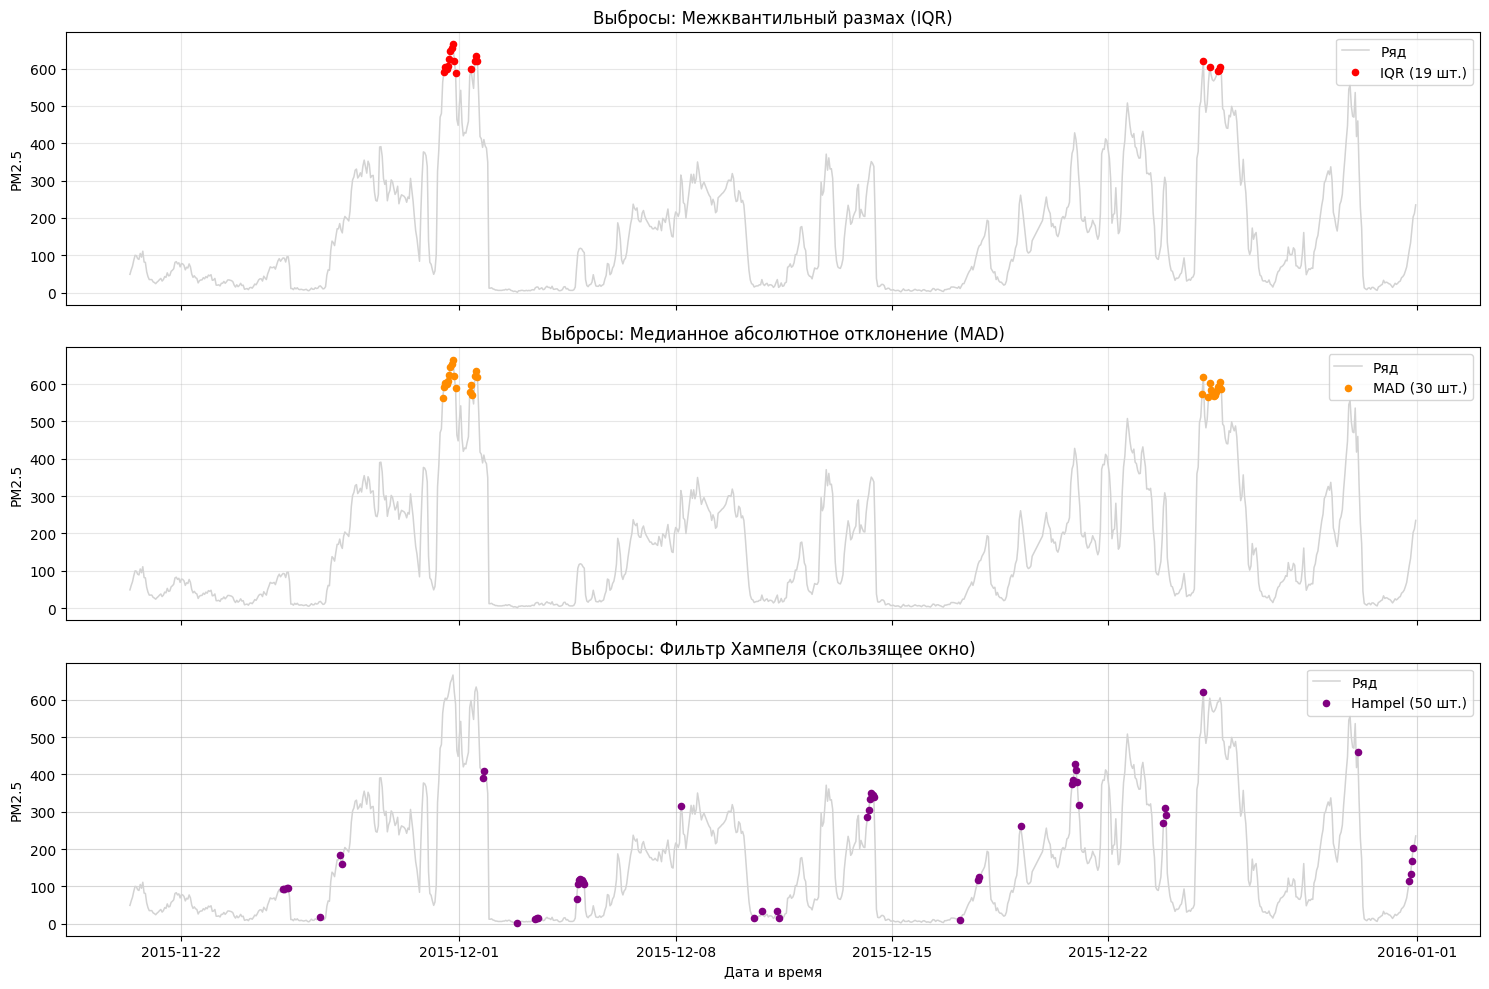

In [84]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# 1. Межквантильный размах (IQR)
axes[0].plot(series.index, series, color='lightgray', linewidth=1.1, label='Ряд')
axes[0].scatter(series.index[outliers_mask], series[outliers_mask],
                color='red', s=20, label=f'IQR ({outliers_mask.sum()} шт.)', zorder=3)
axes[0].set_title('Выбросы: Межквантильный размах (IQR)')
axes[0].set_ylabel('PM2.5')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Медианное абсолютное отклонение (MAD)
axes[1].plot(series.index, series, color='lightgray', linewidth=1.1, label='Ряд')
axes[1].scatter(series.index[outliers_mask1], series[outliers_mask1],
                color='darkorange', s=20, label=f'MAD ({outliers_mask1.sum()} шт.)', zorder=3)
axes[1].set_title('Выбросы: Медианное абсолютное отклонение (MAD)')
axes[1].set_ylabel('PM2.5')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# 3. Фильтр Хампеля
axes[2].plot(series.index, series, color='lightgray', linewidth=1.1, label='Ряд')
axes[2].scatter(series.index[outliers_mask3], series[outliers_mask3],
                color='purple', s=20, label=f'Hampel ({outliers_mask3.sum()} шт.)', zorder=3)
axes[2].set_title('Выбросы: Фильтр Хампеля (скользящее окно)')
axes[2].set_ylabel('PM2.5')
axes[2].set_xlabel('Дата и время')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [85]:

series_cleaned = series.copy()
series_cleaned[outliers_mask3] = np.nan
series_cleaned = series_cleaned.interpolate(method='time')
series_cleaned = series_cleaned.bfill().ffill()
final_df['PM_cleaned'] = series_cleaned
print(f"Заменено выбросов: {outliers_mask3.sum()}")
print(f"Осталось пропусков после интерполяции: {series_cleaned.isna().sum()}")

Заменено выбросов: 50
Осталось пропусков после интерполяции: 0


/tmp/ipykernel_1473/170601171.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['PM_cleaned'] = series_cleaned


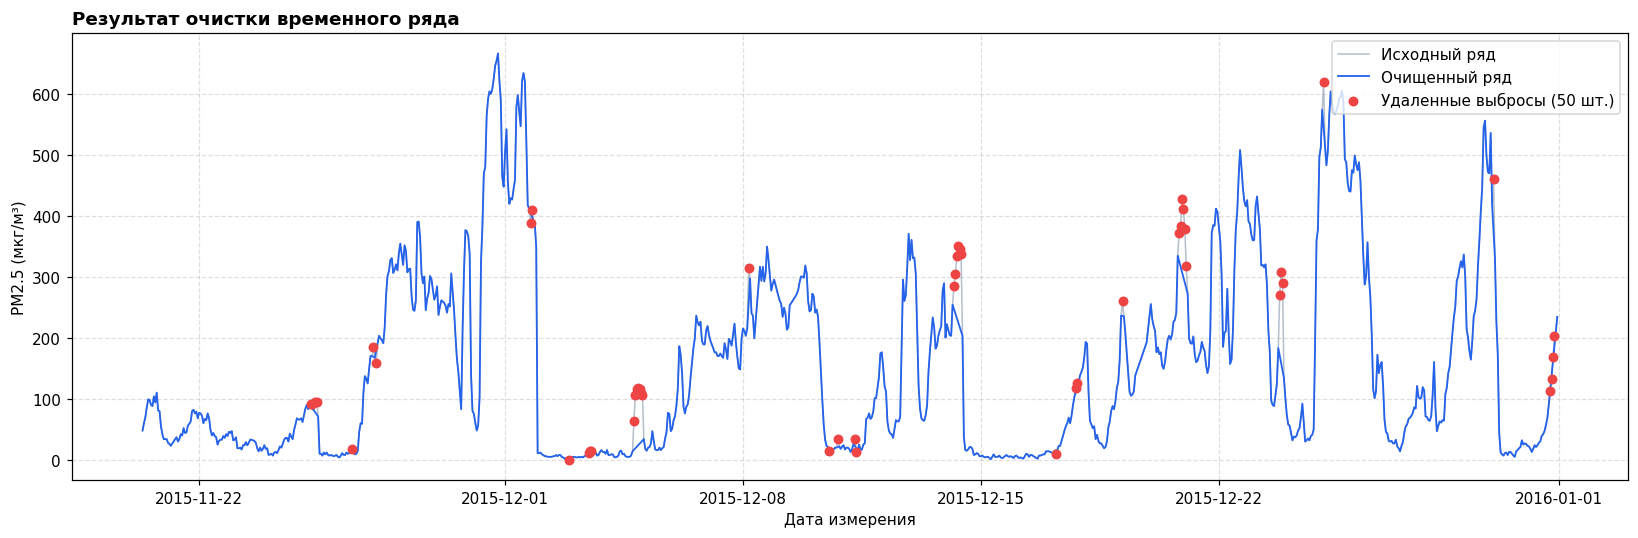

In [86]:
plt.figure(figsize=(15, 5), dpi=110)
plt.plot(series.index, series, color='#94a3b8', linewidth=1, label='Исходный ряд', alpha=0.7)
plt.plot(series_cleaned.index, series_cleaned, color='#2563eb', linewidth=1.2, label='Очищенный ряд')
plt.scatter(series.index[outliers_mask3], series[outliers_mask3],
            color='#ef4444', s=30, label=f'Удаленные выбросы ({outliers_mask3.sum()} шт.)', zorder=4)

plt.title('Результат очистки временного ряда', fontsize=12, fontweight='bold', loc='left')
plt.xlabel('Дата измерения')
plt.ylabel('PM2.5 (мкг/м³)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Видно, что методы межквартильного рахмаха и МАЗ отметили выбросами максимальные значения, но проблема в том, что такие значения частиц вполне возможны. Фильтр Хампеля же выбрал отдельные значения в 24-часовом окне, из-за чего такие выбросы можно считать реальными выбросами.

In [87]:
series_cleaned

,PM_US Post
datetime,
2015-11-20 08:00:00,49.0
2015-11-20 09:00:00,61.0
2015-11-20 10:00:00,71.0
2015-11-20 11:00:00,87.0
2015-11-20 12:00:00,100.0
...,...
2015-12-31 19:00:00,139.4
2015-12-31 20:00:00,163.6
2015-12-31 21:00:00,187.8


5

# 6. Методы сглаживания

In [89]:
series_cleaned

,PM_US Post
datetime,
2015-11-20 08:00:00,49.0
2015-11-20 09:00:00,61.0
2015-11-20 10:00:00,71.0
2015-11-20 11:00:00,87.0
2015-11-20 12:00:00,100.0
...,...
2015-12-31 19:00:00,139.4
2015-12-31 20:00:00,163.6
2015-12-31 21:00:00,187.8


In [90]:
n_points = len(series_cleaned)
values = series_cleaned.values

mov_mean = series_cleaned.rolling(window=25, center=True, min_periods=1).mean()

mov_med = series_cleaned.rolling(window=25, center=True, min_periods=1).median()

sav_gol = pd.Series(
    savgol_filter(values, window_length=25, polyorder=2),
    index=series_cleaned.index
)

fft_coef = np.fft.rfft(values)
n_harmonics = 35
fft_filtered = np.zeros_like(fft_coef)
fft_filtered[:n_harmonics] = fft_coef[:n_harmonics]

fft = pd.Series(
    np.fft.irfft(fft_filtered, n=n_points),
    index=series_cleaned.index
)


X = values.reshape(1, -1)
ssa_model = SingularSpectrumAnalysis(window_size=72, groups=[[0, 1, 2]])
X_ssa = ssa_model.fit_transform(X)

ssa = pd.Series(
    X_ssa[0],
    index=series_cleaned.index
)

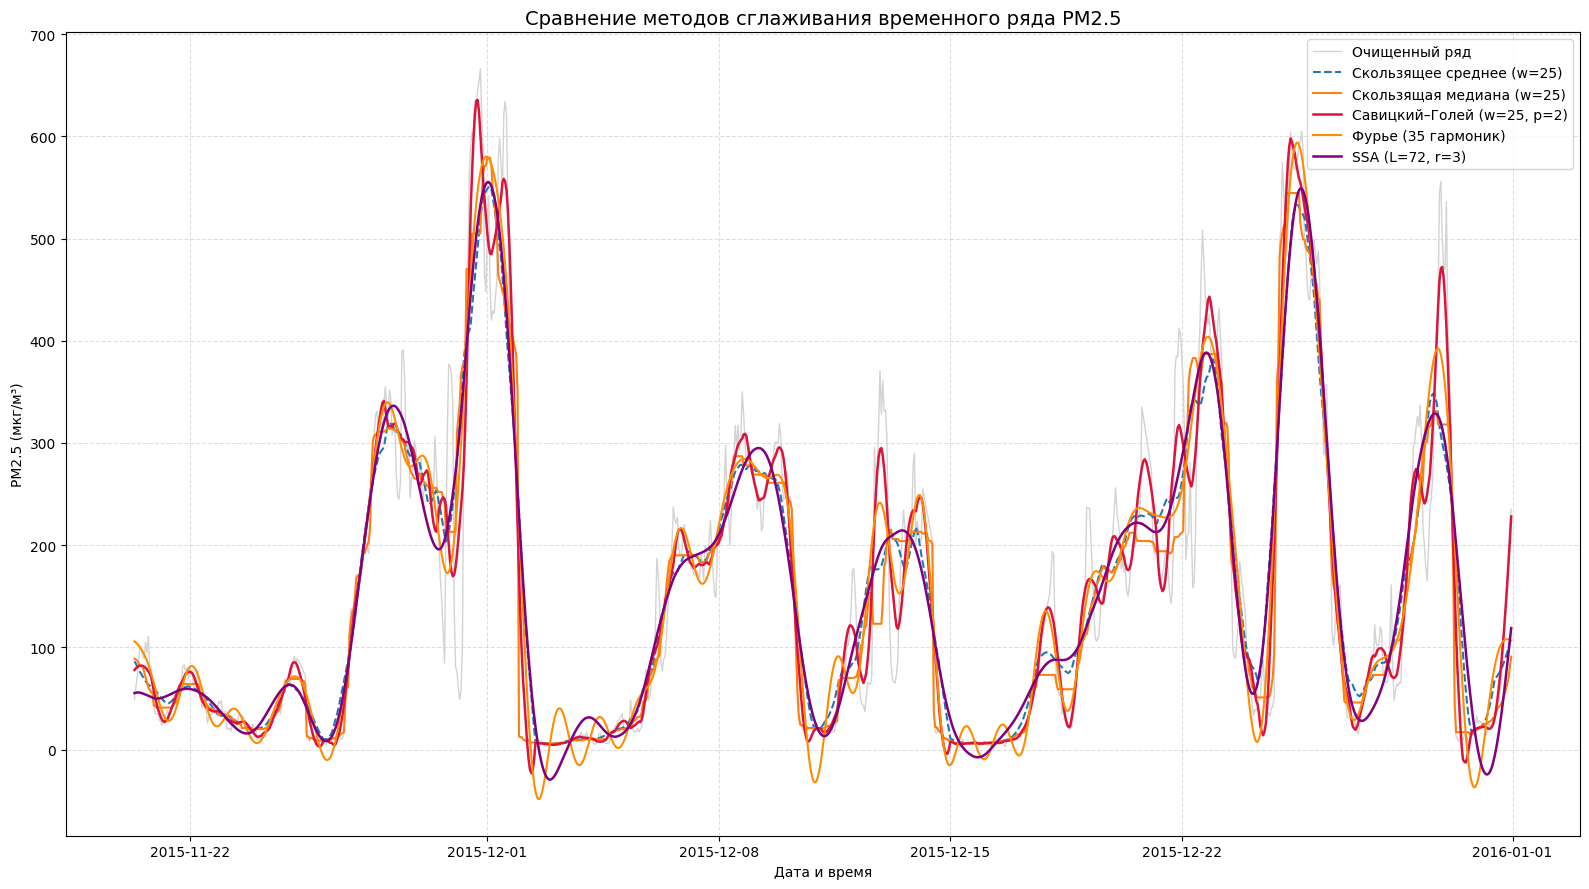

In [91]:
plt.figure(figsize=(16, 9))

plt.plot(series_cleaned.index, series_cleaned, color='lightgray', linewidth=1, label='Очищенный ряд')

plt.plot(series_cleaned.index, mov_mean, label='Скользящее среднее (w=25)', linewidth=1.5, linestyle='--')
plt.plot(series_cleaned.index, mov_med, label='Скользящая медиана (w=25)', linewidth=1.5)
plt.plot(series_cleaned.index, sav_gol, label='Савицкий–Голей (w=25, p=2)', linewidth=1.8, color='crimson')
plt.plot(series_cleaned.index, fft, label='Фурье (35 гармоник)', linewidth=1.5, color='darkorange')
plt.plot(series_cleaned.index, ssa, label='SSA (L=72, r=3)', linewidth=1.8, color='purple')

plt.title('Сравнение методов сглаживания временного ряда PM2.5', fontsize=14)
plt.xlabel('Дата и время')
plt.ylabel('PM2.5 (мкг/м³)')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 7. Проверка стационарности

In [92]:
series_savgol = sav_gol
adf_savgol = adfuller(series_savgol, autolag='AIC')
kpss_savgol = kpss(series_savgol, regression='c', nlags='auto')

print(f"Савицкий-Голей – ADF p-value:  {adf_savgol[1]:.4e}")
print(f"Савицкий-Голей – KPSS p-value: {kpss_savgol[1]:.4e}")

if adf_savgol[1] < alpha:
    print(f"Вывод ADF:  p-value < {alpha} -> H0 отвергается. Ряд СТАЦИОНАРЕН.")
else:
    print(
        f"Вывод ADF:  p-value >= {alpha} -> H0 принимается. Ряд НЕСТАЦИОНАРЕН."
    )

if kpss_savgol[1] < alpha:
    print(
        f"Вывод KPSS: p-value < {alpha} -> H0 отвергается. Ряд НЕСТАЦИОНАРЕН."
    )
else:
    print(
        f"Вывод KPSS: p-value >= {alpha} -> H0 принимается. Ряд СТАЦИОНАРЕН."
    )

Савицкий-Голей – ADF p-value:  2.4819e-04
Савицкий-Голей – KPSS p-value: 1.0000e-01
Вывод ADF:  p-value < 0.05 -> H0 отвергается. Ряд СТАЦИОНАРЕН.
Вывод KPSS: p-value >= 0.05 -> H0 принимается. Ряд СТАЦИОНАРЕН.


/tmp/ipykernel_1473/2212270037.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_savgol = adfuller(series_savgol, autolag='AIC')
/tmp/ipykernel_1473/2212270037.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_savgol = kpss(series_savgol, regression='c', nlags='auto')
/tmp/ipykernel_1473/2212270037.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch 

In [93]:
series_clean = series_cleaned
adf_clean = adfuller(series_clean, autolag='AIC')
kpss_clean = kpss(series_clean, regression='c', nlags='auto')

print(f"Очищенные данные – ADF p-value:  {adf_clean[1]:.4e}")
print(f"Очищенные данные – KPSS p-value: {kpss_clean[1]:.4e}")

if adf_clean[1] < alpha:
    print(f"Вывод ADF:  p-value < {alpha} -> H0 отвергается. Ряд СТАЦИОНАРЕН.")
else:
    print(
        f"Вывод ADF:  p-value >= {alpha} -> H0 принимается. Ряд НЕСТАЦИОНАРЕН."
    )

# Вывод по тесту KPSS
if kpss_clean[1] < alpha:
    print(
        f"Вывод KPSS: p-value < {alpha} -> H0 отвергается. Ряд НЕСТАЦИОНАРЕН."
    )
else:
    print(
        f"Вывод KPSS: p-value >= {alpha} -> H0 принимается. Ряд СТАЦИОНАРЕН."
    )

Очищенные данные – ADF p-value:  1.0335e-04
Очищенные данные – KPSS p-value: 1.0000e-01
Вывод ADF:  p-value < 0.05 -> H0 отвергается. Ряд СТАЦИОНАРЕН.
Вывод KPSS: p-value >= 0.05 -> H0 принимается. Ряд СТАЦИОНАРЕН.


/tmp/ipykernel_1473/3031477107.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_clean = adfuller(series_clean, autolag='AIC')
/tmp/ipykernel_1473/3031477107.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_clean = kpss(series_clean, regression='c', nlags='auto')
/tmp/ipykernel_1473/3031477107.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to a